In [ ]:
from google.colab import files
uploaded=files.upload()

Saving data.csv to data.csv


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


### Dataset Overview

Let's check the shape (rows, columns), column names, and their data types to understand the structure of our dataset.

In [ ]:
# Display the shape of the DataFrame
print(f"Shape of the dataset: {df.shape}\n")

# Display the column names and their data types
print("Column information (data types and non-null counts):")
df.info()

Shape of the dataset: (170653, 19)

Column information (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 no

### Explanation of Main Features

Now, let's understand some of the key features that are crucial for building our recommendation system:

*   **`valence`**: Describes the musical positiveness conveyed by a track. High valence tracks sound more positive (e.g. happy, cheerful, euphoric), while low valence tracks sound more negative (e.g. sad, depressed, angry).
*   **`year`**: The year the song was released.
*   **`acousticness`**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.
*   **`artists`**: The name(s) of the artist(s) who performed the track.
*   **`danceability`**: Describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.
*   **`duration_ms`**: The duration of the track in milliseconds.
*   **`energy`**: Represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on it.
*   **`explicit`**: Whether the track contains explicit lyrics (true or false).
*   **`id`**: The Spotify ID for the track.
*   **`instrumentalness`**: Predicts whether a track contains no vocals. The closer the instrumentalness value is to 1.0, the greater the likelihood the track contains no vocal content.
*   **`key`**: The estimated overall key of the track. Integers map to pitches using standard Pitch Class notation (e.g., 0 = C, 1 = C#).
*   **`liveness`**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live.
*   **`loudness`**: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks.
*   **`mode`**: Indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.
*   **`name`**: The name of the track.
*   **`popularity`**: The popularity of the track, ranging from 0 to 100, with 100 being the most popular.
*   **`release_date`**: The date when the track was released.
*   **`speechiness`**: Detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g., talk show, audiobook), the closer to 1.0 the attribute value.
*   **`tempo`**: The overall estimated tempo of a track in beats per minute (BPM).
*   **`artist_top_genre`**: The top genre associated with the artist.
*   **`genres`**: A list of genres associated with the track.


### Handle Missing Values

Based on the `df.info()` output, there are no explicit missing values (all columns show `170653 non-null` entries, which matches the total number of rows). So, we can skip handling missing values for now. However, it's good practice to always check for them.

### Remove Duplicates

We need to ensure that our dataset contains unique song entries to avoid any bias in our recommendation system. We'll check for duplicate rows and remove them if any are found. We will consider a row duplicated if all its column values are identical to another row.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed successfully.")
    print(f"New shape of the dataset: {df.shape}")
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


### Fix Data Types

From the `df.info()` output, we observed that the `release_date` column is currently of `object` type. For proper time-series analysis or filtering by date, it's beneficial to convert this column to a `datetime` object. We will also extract the `year` from `release_date` and ensure `year` is an integer type, as it could be useful later on.

In [ ]:
# Convert 'release_date' to datetime objects, coercing errors to NaT
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce', format='mixed')
print("Converted 'release_date' to datetime, handling unparseable dates.")

# Extract year from 'release_date' and ensure 'year' column is integer type
df['year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Verify data types after conversion
print("\nUpdated Column Information:")
df.info()

Converted 'release_date' to datetime, handling unparseable dates.

Updated Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   valence           170653 non-null  float64       
 1   year              170653 non-null  int64         
 2   acousticness      170653 non-null  float64       
 3   artists           170653 non-null  object        
 4   danceability      170653 non-null  float64       
 5   duration_ms       170653 non-null  int64         
 6   energy            170653 non-null  float64       
 7   explicit          170653 non-null  int64         
 8   id                170653 non-null  object        
 9   instrumentalness  170653 non-null  float64       
 10  key               170653 non-null  int64         
 11  liveness          170653 non-null  float64       
 12  loudness          1

### Phase 3: Exploratory Data Analysis (EDA)

Now that our data is clean, let's perform some exploratory data analysis to understand the distributions of key features and identify potential relationships between them.

#### Distributions of Key Features

We will visualize the distributions of important audio features like `danceability`, `energy`, `valence`, `tempo`, and `loudness` using histograms. This will help us understand their ranges and common values within our dataset.

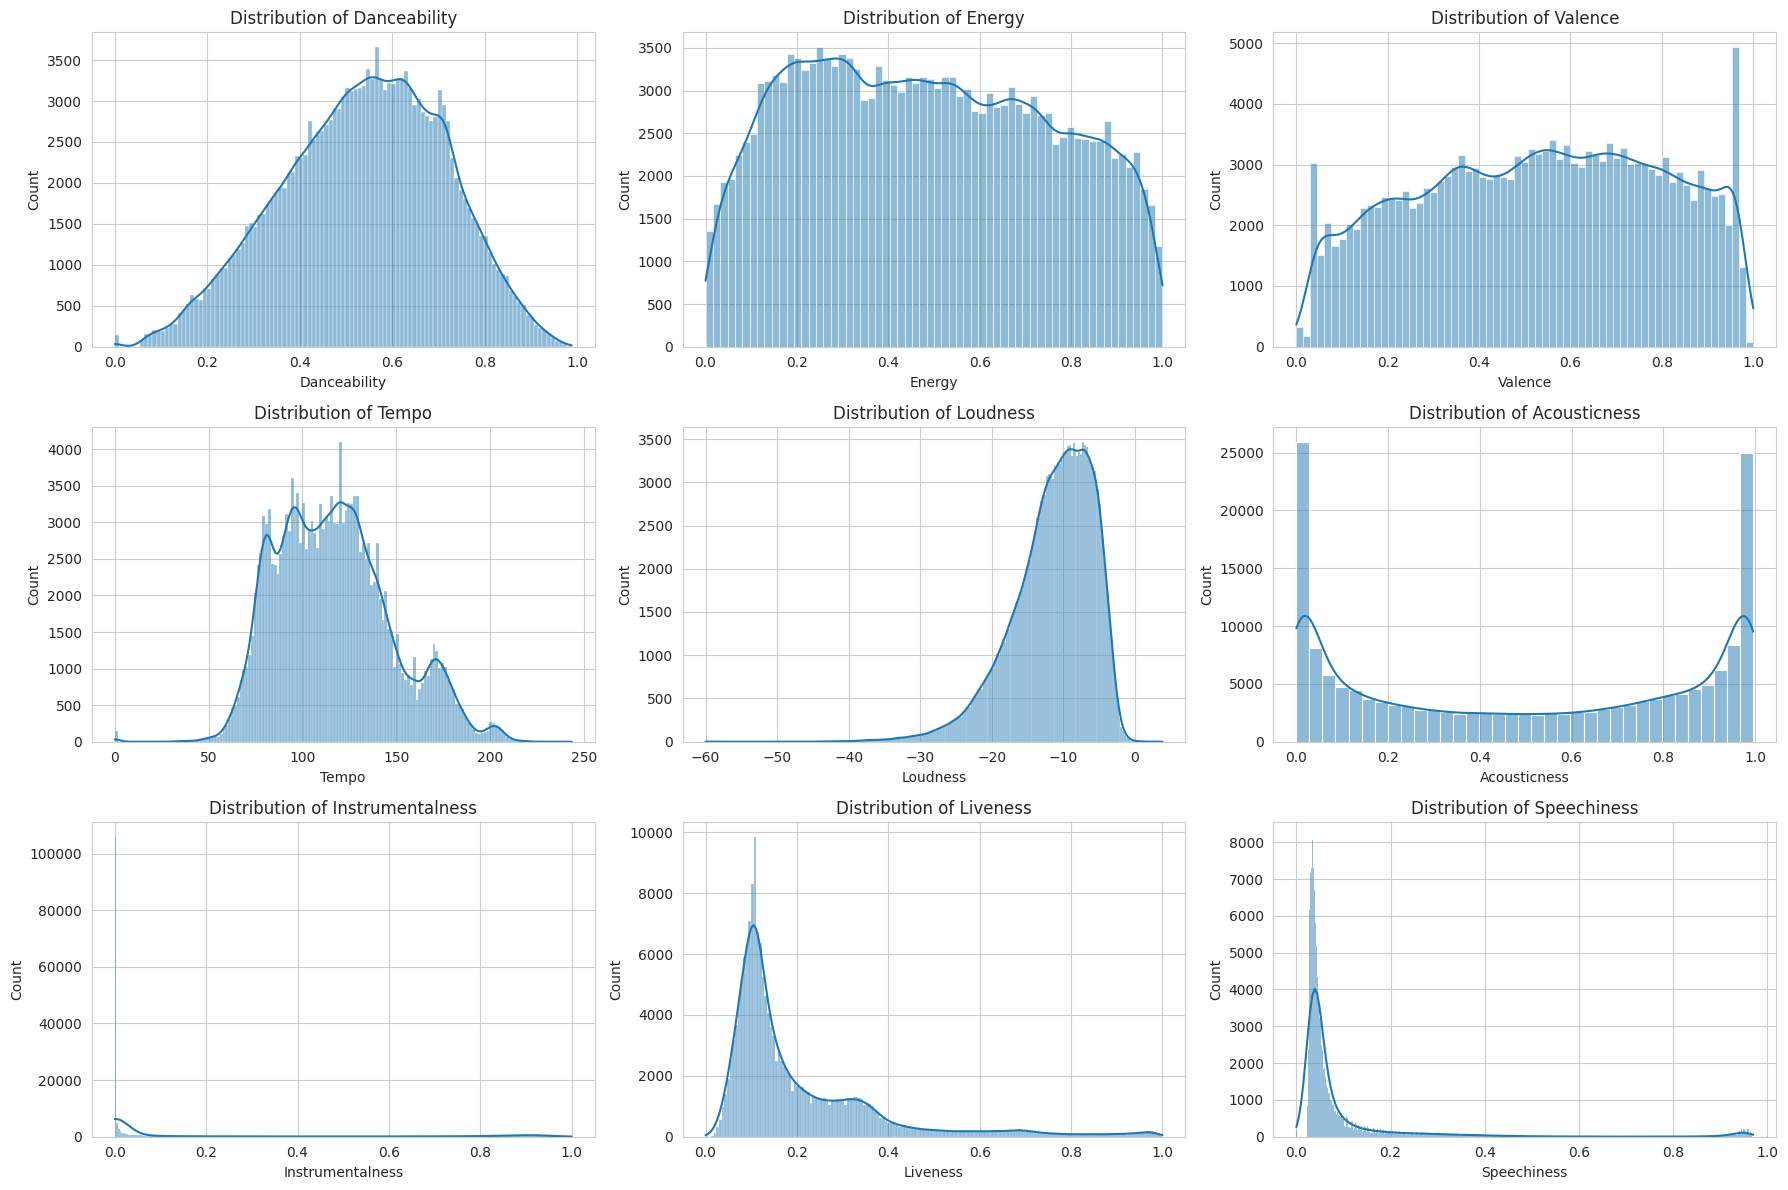

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# List of features to visualize
features_to_plot = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']

# Create subplots
plt.figure(figsize=(18, 12))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.histplot(df[feature], kde=True) # Create a histogram with a Kernel Density Estimate
    plt.title(f'Distribution of {feature.replace("_", " ").title()}') # Set title with formatted feature name
    plt.xlabel(feature.replace("_", " ").title()) # Set x-axis label
    plt.ylabel('Count') # Set y-axis label

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show() # Display the plots

#### Correlation Matrix

Next, we'll compute and visualize the correlation matrix for the numerical features. This will help us understand how different audio features relate to each other. A high positive correlation (close to 1) means that as one feature increases, the other tends to increase as well. A high negative correlation (close to -1) means that as one feature increases, the other tends to decrease. A correlation close to 0 suggests little to no linear relationship.

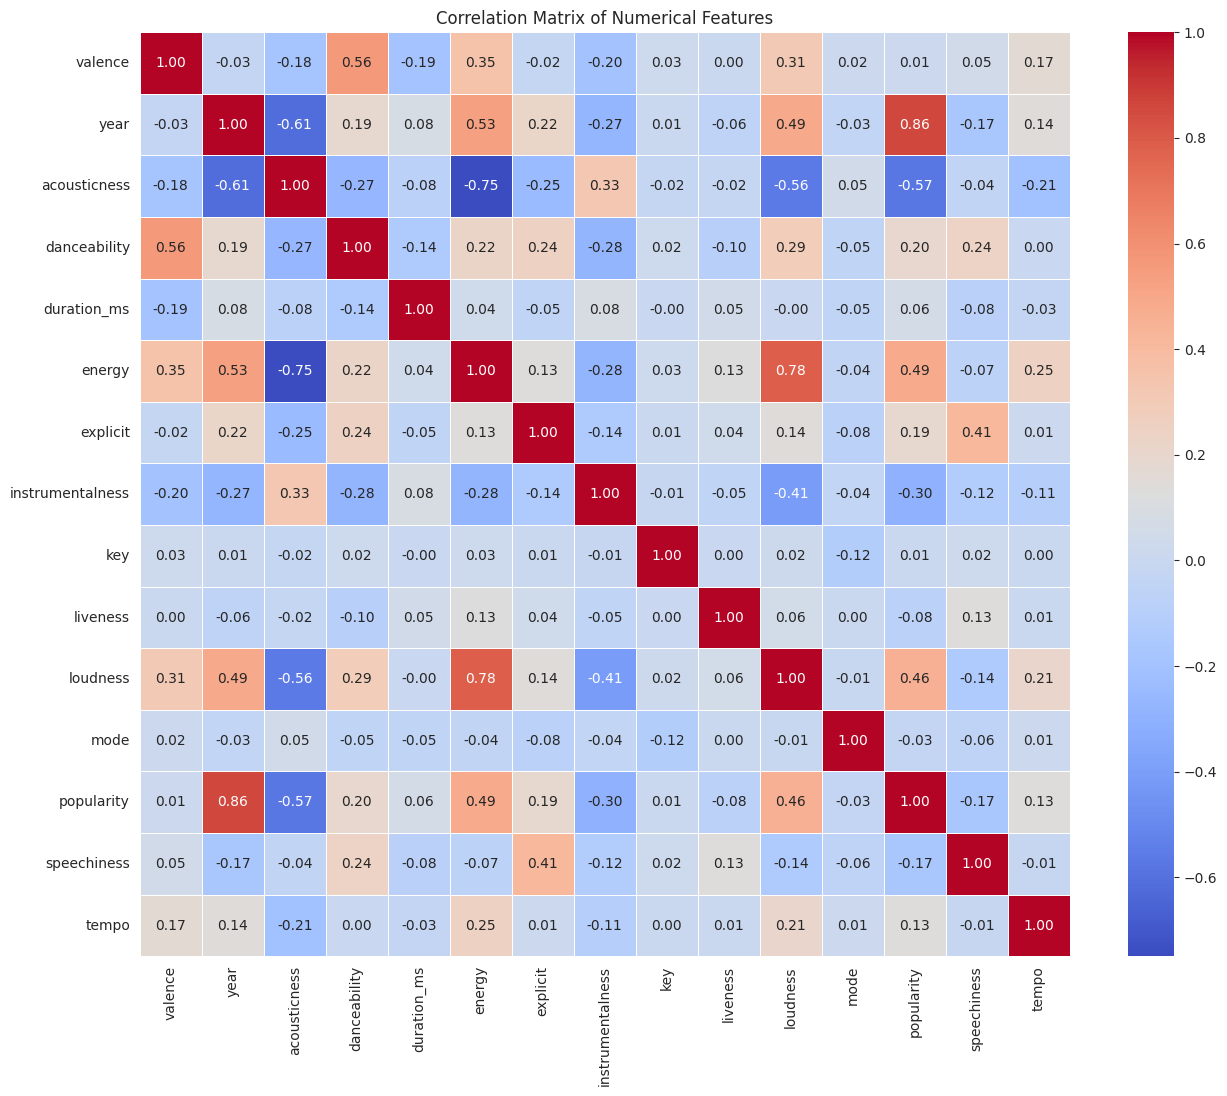

In [ ]:
# Select only the numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(15, 12)) # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # Create heatmap
plt.title('Correlation Matrix of Numerical Features') # Set the title of the heatmap
plt.show() # Display the heatmap

#### Explaining Insights from EDA

After examining the distributions and correlation matrix, we'll explain the key insights gained from our EDA.

### Handle Missing Values

Based on the `df.info()` output, there are no explicit missing values (all columns show `170653 non-null` entries, which matches the total number of rows). So, we can skip handling missing values for now. However, it's good practice to always check for them.

### Remove Duplicates

We need to ensure that our dataset contains unique song entries to avoid any bias in our recommendation system. We'll check for duplicate rows and remove them if any are found. We will consider a row duplicated if all its column values are identical to another row.

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows if any exist
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed successfully.")
    print(f"New shape of the dataset: {df.shape}")
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


### Fix Data Types

From the `df.info()` output, we observed that the `release_date` column is currently of `object` type. For proper time-series analysis or filtering by date, it's beneficial to convert this column to a `datetime` object. We will also extract the `year` from `release_date` and ensure `year` is an integer type, as it could be useful later on.

In [ ]:
# Convert 'release_date' to datetime objects, coercing errors to NaT
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce', format='mixed')
print("Converted 'release_date' to datetime, handling unparseable dates.")

# Extract year from 'release_date'
# Fill NaT dates with a placeholder year (e.g., 0) before converting to int
df['year'] = df['release_date'].dt.year.fillna(0).astype(int)

# Verify data types after conversion
print("\nUpdated Column Information:")
df.info()

Converted 'release_date' to datetime, handling unparseable dates.

Updated Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   valence           170653 non-null  float64       
 1   year              170653 non-null  int64         
 2   acousticness      170653 non-null  float64       
 3   artists           170653 non-null  object        
 4   danceability      170653 non-null  float64       
 5   duration_ms       170653 non-null  int64         
 6   energy            170653 non-null  float64       
 7   explicit          170653 non-null  int64         
 8   id                170653 non-null  object        
 9   instrumentalness  170653 non-null  float64       
 10  key               170653 non-null  int64         
 11  liveness          170653 non-null  float64       
 12  loudness          1

### Phase 4: Feature Preparation

In this phase, we will prepare our data for model building by selecting the relevant numerical audio features. These features will be used to create our feature matrix `X`, which is essential for calculating song similarities.

In [ ]:
# Define the list of numerical audio features to be used
# These features are typically used to describe the sonic characteristics of a song
audio_features = [
    'valence',
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'popularity' # Including popularity as it's a quantitative measure of song success
]

# Create the feature matrix X by selecting these columns from the DataFrame
X = df[audio_features]

print("Feature matrix X created successfully with the following audio features:")
print(X.head())
print(f"\nShape of the feature matrix X: {X.shape}")

Feature matrix X created successfully with the following audio features:
   valence  acousticness  danceability  energy  instrumentalness  liveness  \
0   0.0594         0.982         0.279   0.211          0.878000     0.665   
1   0.9630         0.732         0.819   0.341          0.000000     0.160   
2   0.0394         0.961         0.328   0.166          0.913000     0.101   
3   0.1650         0.967         0.275   0.309          0.000028     0.381   
4   0.2530         0.957         0.418   0.193          0.000002     0.229   

   loudness  speechiness    tempo  popularity  
0   -20.096       0.0366   80.954           4  
1   -12.441       0.4150   60.936           5  
2   -14.850       0.0339  110.339           5  
3    -9.316       0.0354  100.109           3  
4   -10.096       0.0380  101.665           2  

Shape of the feature matrix X: (170653, 10)


### Phase 5: Feature Scaling

In this phase, we will scale our numerical audio features using `StandardScaler`. This is a crucial preprocessing step for many machine learning algorithms, especially those that rely on distance calculations, such as K-Nearest Neighbors (KNN) and cosine similarity, which we will be using for our recommendation system.

#### Why is Feature Scaling Important?

1.  **Equal Contribution**: Features with larger numerical ranges might dominate the distance calculations. For example, if `loudness` ranges from -60 to 0 dB and `danceability` from 0 to 1, `loudness` changes would have a much larger impact on the distance than `danceability` changes. Scaling ensures all features contribute proportionally.
2.  **Algorithm Performance**: Many machine learning algorithms (like KNN, SVMs, neural networks) perform better or converge faster when features are on a similar scale.
3.  **Preventing Bias**: Scaling helps prevent features with inherently larger values from biasing the model towards them.

`StandardScaler` transforms data such that its distribution has a mean of 0 and a standard deviation of 1 (unit variance). This is achieved by subtracting the mean and then dividing by the standard deviation for each feature.

### Phase 8: Example Usage of Recommendation Systems

Now that we have built both the song-to-song and mood-based recommendation functions, let's see them in action with some example usage.

#### Example 1: Song-to-Song Recommendation

Let's find some songs similar to a well-known track. We'll use 'Bohemian Rhapsody' by Queen as an example.

In [ ]:
# Example usage of song-to-song recommendation
song_to_find = "Bohemian Rhapsody"
recommendations_song = get_song_recommendations(song_to_find, df, X_scaled_df, num_recommendations=5)
print(recommendations_song)

Top 5 song recommendations for 'Bohemian Rhapsody - Remastered 2011' by ['Queen']:

                                               name  \
16920                             Bohemian Rhapsody   
70314  I Don't Want to Talk About It - 1989 Version   
10207                                      Dream On   
9806                                    Tiny Dancer   
36103                            Perfume a Tus Pies   

                           artists release_date  
16920                    ['Queen']   2006-01-01  
70314              ['Rod Stewart']   1996-11-12  
10207                ['Aerosmith']   1973-01-05  
9806                ['Elton John']   1971-11-05  
36103  ['En Espíritu Y En Verdad']   2007-12-11  


#### Example 2: Mood-Based Music Finder

Let's imagine a user is looking for upbeat, danceable, and energetic music. We'll define a mood vector for this.

In [ ]:
# Example usage of mood-based recommendation
user_mood = {
    'valence': 0.9,          # Very positive/happy
    'acousticness': 0.1,     # Not very acoustic (more electronic/produced)
    'danceability': 0.8,     # Very danceable
    'energy': 0.9,           # High energy
    'instrumentalness': 0.0, # Contains vocals
    'liveness': 0.1,         # Studio recorded
    'loudness': 0.7,         # Moderately loud
    'speechiness': 0.05,     # Not much spoken word
    'tempo': 130,            # Fast tempo (BPM)
    'popularity': 75         # Reasonably popular
}

recommendations_mood = get_mood_based_recommendations(user_mood, df, X_scaled_df, audio_features, num_recommendations=5)
print(recommendations_mood)

Top 5 song recommendations for your mood:

                     name                                       artists  \
36659           Rechazame                              ['Prince Royce']   
14676              Gloria                            ['Laura Branigan']   
169178  Si No Te Quisiera  ['Juan Magán', 'Belinda', 'Lapiz Conciente']   
123927          VERY NICE                                 ['SEVENTEEN']   
122822    Baja la Tensión                         ['Cultura Profética']   

       release_date  
36659    2010-01-01  
14676    1995-06-06  
169178   2013-07-22  
123927   2016-07-04  
122822   2010-08-23  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


### Phase 7: Mood-Based Music Finder

In this phase, we will develop a function to recommend songs based on a user's specified mood, leveraging the K-Nearest Neighbors (KNN) algorithm. This allows users to find songs that match their current emotional state or desired listening experience.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def get_mood_based_recommendations(user_mood_values, df, X_scaled_df, audio_features, num_recommendations=10):
    """
    Recommends songs based on user-defined mood values using K-Nearest Neighbors.

    Args:
        user_mood_values (dict): A dictionary where keys are audio features and values are the desired mood levels.
                                 Example: {'energy': 0.8, 'danceability': 0.7, 'valence': 0.9}
        df (pd.DataFrame): The original DataFrame containing song information.
        X_scaled_df (pd.DataFrame): The scaled feature matrix DataFrame.
        audio_features (list): The list of audio features used in X_scaled_df.
        num_recommendations (int): The number of top closest songs to recommend.

    Returns:
        pd.DataFrame: A DataFrame containing the recommended songs and their artists.
    """
    # Create a user mood vector from the input dictionary, ensuring order matches audio_features
    user_vector = pd.DataFrame([user_mood_values], columns=audio_features)

    # Scale the user vector using the same scaler fitted on X_scaled_df
    # We need to reuse the `scaler` object from Phase 5
    user_vector_scaled = scaler.transform(user_vector)

    # Initialize NearestNeighbors model
    # We use 'cosine' metric because it's effective for high-dimensional data and normalized vectors
    # 'brute' algorithm is used for simplicity; 'auto' can be used for larger datasets
    knn = NearestNeighbors(n_neighbors=num_recommendations + 1, algorithm='brute', metric='cosine')

    # Fit the KNN model on the scaled song features
    knn.fit(X_scaled_df)

    # Find the k-nearest neighbors to the user's mood vector
    # distances[0] contains the distances, indices[0] contains the indices of the neighbors
    distances, indices = knn.kneighbors(user_vector_scaled)

    # Get the indices of the recommended songs (excluding the user's own input if it were a song)
    # The first neighbor is typically the query itself, so we skip it.
    recommended_song_indices = indices[0][1:num_recommendations+1]

    # Get the recommended songs details
    recommended_songs = df.iloc[recommended_song_indices][['name', 'artists', 'release_date']]

    print(f"Top {num_recommendations} song recommendations for your mood:\n")
    return recommended_songs

print("Mood-based recommendation function 'get_mood_based_recommendations' defined.")

Mood-based recommendation function 'get_mood_based_recommendations' defined.


### Phase 6: Song-to-Song Recommendation

In this phase, we will build a function that takes a song name as input and recommends similar songs using cosine similarity. This is a core part of our content-based recommendation system.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_song_recommendations(song_name, df, X_scaled_df, num_recommendations=10):
    """
    Recommends songs similar to the input song using cosine similarity.

    Args:
        song_name (str): The name of the song to get recommendations for.
        df (pd.DataFrame): The original DataFrame containing song information.
        X_scaled_df (pd.DataFrame): The scaled feature matrix DataFrame.
        num_recommendations (int): The number of top similar songs to recommend.

    Returns:
        pd.DataFrame: A DataFrame containing the recommended songs and their artists.
    """
    # Find the index of the input song
    song_index = df[df['name'].str.contains(song_name, case=False, na=False)].index

    if song_index.empty:
        print(f"Song '{song_name}' not found in the dataset. Please try another song.")
        return pd.DataFrame()

    # Take the first match if multiple songs have similar names
    song_index = song_index[0]

    # Get the feature vector of the input song
    input_song_features = X_scaled_df.iloc[song_index].values.reshape(1, -1)

    # Calculate cosine similarity between the input song and all other songs
    similarities = cosine_similarity(input_song_features, X_scaled_df)

    # Get the indices of the most similar songs (excluding the input song itself)
    # Flatten the similarities array to easily sort and get top N
    similar_song_indices = similarities.argsort()[0][::-1][1:num_recommendations+1]

    # Get the recommended songs details
    recommended_songs = df.iloc[similar_song_indices][['name', 'artists', 'release_date']]

    print(f"Top {num_recommendations} song recommendations for '{df.loc[song_index, 'name']}' by {df.loc[song_index, 'artists']}:\n")
    return recommended_songs

print("Song recommendation function 'get_song_recommendations' defined.")

Song recommendation function 'get_song_recommendations' defined.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the feature matrix X and transform the data
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for better readability and to retain column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature matrix X scaled successfully!")
print("\nFirst 5 rows of the scaled feature matrix:")
print(X_scaled_df.head())
print(f"\nShape of the scaled feature matrix: {X_scaled_df.shape}")

Feature matrix X scaled successfully!

First 5 rows of the scaled feature matrix:
    valence  acousticness  danceability    energy  instrumentalness  liveness  \
0 -1.782825      1.276187     -1.467013 -1.013988          2.268102  2.626719   
1  1.650688      0.611347      1.598779 -0.528270         -0.532771 -0.262229   
2 -1.858821      1.220340     -1.188820 -1.182122          2.379754 -0.599749   
3 -1.381564      1.236296     -1.489722 -0.647832         -0.532682  1.002043   
4 -1.047180      1.209703     -0.677855 -1.081242         -0.532765  0.132499   

   loudness  speechiness     tempo  popularity  
0 -1.514237    -0.379706 -1.169307   -1.256808  
1 -0.170766     1.945481 -1.821180   -1.210993  
2 -0.593551    -0.396297 -0.212404   -1.210993  
3  0.377680    -0.387080 -0.545537   -1.302624  
4  0.240788    -0.371104 -0.494867   -1.348440  

Shape of the scaled feature matrix: (170653, 10)


In [ ]:
import ast

user_input = input("Entrez le nom d'une chanson ou d'un artiste : ")

# Try to find a song first
song_matches = df[df['name'].str.contains(user_input, case=False, na=False)]

if not song_matches.empty:
    # If song found, get recommendations
    print(f"\nRecherche de recommandations pour la chanson : '{user_input}'...")
    recommendations = get_song_recommendations(user_input, df, X_scaled_df, num_recommendations=10)
    if not recommendations.empty:
        display(recommendations)
    else:
        print(f"Aucune recommandation trouvée pour la chanson '{user_input}'.")
elif any(df['artists'].apply(lambda x: user_input.lower() in x.lower() if isinstance(x, str) else False)):
    # If not a song, check for artist (handle list-like string format)
    print(f"\nRecherche de chansons de l'artiste : '{user_input}'...")
    # Convert the string representation of list to actual list for filtering
    artist_songs = df[df['artists'].apply(lambda x: user_input.lower() in x.lower() if isinstance(x, str) else False)]

    if not artist_songs.empty:
        # Display only name, artists, and release_date for artist's songs
        display(artist_songs[['name', 'artists', 'release_date']].head(20)) # Display top 20 songs by the artist
    else:
        print(f"Aucune chanson trouvée pour l'artiste '{user_input}'.")
else:
    print(f"Ni chanson ni artiste correspondant à '{user_input}' trouvés dans le dataset. Veuillez essayer un autre nom.")


Entrez le nom d'une chanson ou d'un artiste : 'Ed Sheeran

Recherche de chansons de l'artiste : ''Ed Sheeran'...


,name,artists,release_date
17861,The A Team,['Ed Sheeran'],2011-09-09
17885,Kiss Me,['Ed Sheeran'],2011-09-09
17909,Give Me Love,['Ed Sheeran'],2011-09-09
17985,Lego House,['Ed Sheeran'],2011-09-09
18193,Everything Has Changed,"['Taylor Swift', 'Ed Sheeran']",2012-10-22
18259,Thinking out Loud,['Ed Sheeran'],2013-01-01
18274,Photograph,['Ed Sheeran'],2013-01-01
18320,I See Fire,['Ed Sheeran'],2013-12-10
18425,Thinking out Loud,['Ed Sheeran'],2014-06-21
18439,Photograph,['Ed Sheeran'],2014-06-21


In [ ]:
# Export CSV sans index
df.to_csv("output.csv", index=False)

In [ ]:
from google.colab import files

files.download("output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>